# 0 (Pre-requisite). Importing necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.ticker as ticker


# 1. Loading tables

## 1.1: Data_Dictionary.csv

- This is a table that acts as a dictionary that provides descriptions for all other tables in the 'Global Electronics Retailer' database.
- The table has 37 rows and 3 attributes, from which we can refer that there are a total of 37 attributes across the entire database split between the different tables.

In [2]:
Data_Dict=pd.read_csv('Global+Electronics+Retailer/Data_Dictionary.csv')
Data_Dict.head(10)

,Table,Field,Description
0,Sales,Order Number,Unique ID for each order
1,Sales,Line Item,Identifies individual products purchased as pa...
2,Sales,Order Date,Date the order was placed
3,Sales,Delivery Date,Date the order was delivered
4,Sales,CustomerKey,Unique key identifying which customer placed t...
5,Sales,StoreKey,Unique key identifying which store processed t...
6,Sales,ProductKey,Unique key identifying which product was purch...
7,Sales,Quantity,Number of items purchased
8,Sales,Currency Code,Currency used to process the order
9,Customers,CustomerKey,Primary key to identify customers


## 1.1: Customers.csv

- A table that keeps customer details. 
- It consists of 15,266 rows and 10 features.

In [3]:
Customers = pd.read_csv('Global+Electronics+Retailer/Customers.csv', encoding='latin1')
Customers.head()

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,11/19/1965


#### X Checking for missing values

- As can be seen from the output we have 10 missing values in tthe 'State Code' attribute.

In [4]:
Customers.isnull().sum()

CustomerKey     0
Gender          0
Name            0
City            0
State Code     10
State           0
Zip Code        0
Country         0
Continent       0
Birthday        0
dtype: int64

#### X Checking the table shape

- The table has 15,266 rows and 10 attributes.

In [5]:
Customers.shape

(15266, 10)

#### X Using the Data_Dictionary csv to obtain the descriptions of the attributes of the Customers table.

- The table has 10 attributes.

In [6]:
print(Data_Dict[Data_Dict['Table']=='Customers'])

        Table        Field                        Description
9   Customers  CustomerKey  Primary key to identify customers
10  Customers       Gender                    Customer gender
11  Customers         Name                 Customer full name
12  Customers         City                      Customer city
13  Customers   State Code       Customer state (abbreviated)
14  Customers        State              Customer state (full)
15  Customers     Zip Code                  Customer zip code
16  Customers      Country                   Customer country
17  Customers    Continent                 Customer continent
18  Customers     Birthday             Customer date of birth


## 1.2: Sales.csv

- A table that records all sales transactions between the retailer and customers.
- It consists of 62,884 rows and 9 attributes.

In [7]:
Sales = pd.read_csv('Global+Electronics+Retailer/Sales.csv', encoding='latin1')
Sales.head()

,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD


#### X Checking for missing values

- As can be seen in the output below, there are 49,719 missing values in the 'Delivery Date' attribute.
- For the sake of simplicity, anywhere a record is missing a delivery date I have decided to treat it as an 'in-store purchase' that was bought within the store without tthe need for being delivered at a later date.

In [8]:
Sales.isnull().sum()

Order Number         0
Line Item            0
Order Date           0
Delivery Date    49719
CustomerKey          0
StoreKey             0
ProductKey           0
Quantity             0
Currency Code        0
dtype: int64

#### X Checking the table shape

- The table has 62,884 rows and 9 attributes.

In [9]:
Sales.shape

(62884, 9)

#### X Using the Data_Dictionary csv to obtain the descriptions of the attributes of the Sales table.

- The table has 9 attributes.

In [10]:
print(Data_Dict[Data_Dict['Table']=='Sales'])

   Table          Field                                        Description
0  Sales   Order Number                           Unique ID for each order
1  Sales      Line Item  Identifies individual products purchased as pa...
2  Sales     Order Date                          Date the order was placed
3  Sales  Delivery Date                       Date the order was delivered
4  Sales    CustomerKey  Unique key identifying which customer placed t...
5  Sales       StoreKey  Unique key identifying which store processed t...
6  Sales     ProductKey  Unique key identifying which product was purch...
7  Sales       Quantity                          Number of items purchased
8  Sales  Currency Code                 Currency used to process the order


## 1.3: Exchange_Rates.csv

- A table that keeps records of different currencies and their exchange rates as compared to USD.
- The purpose of this table might be for tracking transactions in different currencies on different dates. E.g: calculating how much 1 product was sold for on 2/4/2016 in Canadian Dollars.

In [11]:
Exchange_Rates = pd.read_csv('Global+Electronics+Retailer/Exchange_Rates.csv', encoding='latin1')
Exchange_Rates.head()

,Date,Currency,Exchange
0,1/1/2015,USD,1.0000
1,1/1/2015,CAD,1.1583
2,1/1/2015,AUD,1.2214
3,1/1/2015,EUR,0.8237
4,1/1/2015,GBP,0.6415


#### X Checking for missing values

- There are no missing values in the table.

In [12]:
Exchange_Rates.isnull().sum()

Date        0
Currency    0
Exchange    0
dtype: int64

#### X Checking the table shape

- The table has 11,215 rows and 3 attributes.

In [13]:
Exchange_Rates.shape

(11215, 3)

#### X Using the Data_Dictionary csv to obtain the descriptions of the attributes of the Exchange rates table.

- The table has 3 attributes.

In [14]:
print(Data_Dict[Data_Dict['Table']=='Exchange Rates'])

             Table     Field                    Description
34  Exchange Rates      Date                           Date
35  Exchange Rates  Currency                  Currency code
36  Exchange Rates  Exchange  Exchange rate compared to USD


## 1.4: Products.csv

- A table that keeps records of different products offered for sale by the retailer.
- It is very detailed, having attributed for unit cost, unit price, category, sub-category, etc.
- It contains 2,517 rows and 10 attributes.

In [15]:
Products = pd.read_csv('Global+Electronics+Retailer/Products.csv', encoding='latin1')
Products.head()

,ProductKey,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,$6.62,$12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,$6.62,$12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,$7.40,$14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,$11.00,$21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,$11.00,$21.57,101,MP4&MP3,1,Audio


#### X Checking for missing values

- The table has no misssing values.

In [16]:
Products.isnull().sum()

ProductKey        0
Product Name      0
Brand             0
Color             0
Unit Cost USD     0
Unit Price USD    0
SubcategoryKey    0
Subcategory       0
CategoryKey       0
Category          0
dtype: int64

#### X Checking the table shape

- The table has 2,517 rows and 10 attributes.

In [17]:
Products.shape

(2517, 10)

#### X Using the Data_Dictionary csv to obtain the descriptions of the attributes of the Products table.

- The table has 10 attributes.


In [18]:
print(Data_Dict[Data_Dict['Table']=='Products'])

       Table           Field                            Description
19  Products      ProductKey       Primary key to identify products
20  Products    Product Name                           Product name
21  Products           Brand                          Product brand
22  Products           Color                          Product color
23  Products   Unit Cost USD     Cost to produce the product in USD
24  Products  Unit Price USD              Product list price in USD
25  Products  SubcategoryKey  Key to identify product subcategories
26  Products     Subcategory               Product subcategory name
27  Products     CategoryKey     Key to identify product categories
28  Products        Category                  Product category name


## 1.5: Stores.csv

- A table that keeps records of all stores that either belong to or sell the Electronic Retailer's details.
- It has 67 rows and 5 attributes. 
- This means that the retailer works with 67 different stores.

In [19]:
Stores = pd.read_csv('Global+Electronics+Retailer/Stores.csv', encoding='latin1')
Stores.head()

,StoreKey,Country,State,Square Meters,Open Date
0,1,Australia,Australian Capital Territory,595.0,1/1/2008
1,2,Australia,Northern Territory,665.0,1/12/2008
2,3,Australia,South Australia,2000.0,1/7/2012
3,4,Australia,Tasmania,2000.0,1/1/2010
4,5,Australia,Victoria,2000.0,12/9/2015


#### X Checking for missing values

- There is only 1 missing value in the 'Square Meters' attribute.
- This might mean that a single store did not provide it's space measurements.

In [20]:
Stores.isnull().sum()

StoreKey         0
Country          0
State            0
Square Meters    1
Open Date        0
dtype: int64

#### X Checking the table shape

- The table has 67 rows and 5 attributes

In [21]:
Stores.shape

(67, 5)

#### X Using the Data_Dictionary csv to obtain the descriptions of the attributes of the Stores table.

- The table has 5 attributes.


In [22]:
print(Data_Dict[Data_Dict['Table']=='Stores'])

     Table          Field                       Description
29  Stores       StoreKey    Primary key to identify stores
30  Stores        Country                     Store country
31  Stores          State                       Store state
32  Stores  Square Meters  Store footprint in square meters
33  Stores      Open Date                   Store open date


# 2. Data Analysis (Sales)

## 2.1: Sales Summary

- The first table I chose to work with was Sales.csv.
- It is a very informative table with foreign keys from other tables.
- It however lacks details about cost, revenue, and profit generated from each transaction.
- My first aim was to create a dataframe based off from Sales that would include Product details so that I could analyse Total costs, Revenue, and Profit.

In [23]:
# Sum the total units purchased per ProductKey
sales_summary = (
    Sales.groupby("ProductKey", as_index=False)["Quantity"]
    .sum()
    .rename(columns={"Quantity": "Total Quantity Sold"})
)

# Merge with Products to attach the Product Name for each ProductKey
# This is so we can better understand the summary
sales_summary = sales_summary.merge(
    Products[["ProductKey", "Product Name", "Unit Cost USD","Unit Price USD"]],
    on="ProductKey",
    how="left",
)

# Clean and convert Unit Price to numeric
if sales_summary["Unit Price USD"].dtype == "object":
    sales_summary["Unit Price USD"] = (
        sales_summary["Unit Price USD"]
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
    )
    sales_summary["Unit Price USD"] = pd.to_numeric(
        sales_summary["Unit Price USD"], errors="coerce"
    )

# Clean and convert Unit Price to numeric.
# This was deemed necessary because the Unit Pice and Unit Cost columns have values recordes as "$ xxxx" which makes it difficult to perorm calculations with.
# Therefore, we will remove the "$" and convert the columns to numeric values.
if sales_summary["Unit Cost USD"].dtype == "object":
    sales_summary["Unit Cost USD"] = (
        sales_summary["Unit Cost USD"]
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
    )
    sales_summary["Unit Cost USD"] = pd.to_numeric(
        sales_summary["Unit Cost USD"], errors="coerce"
    )

# Creating new attributes for Total Revenue, Total Cost, and Total Profit
sales_summary["Total Revenue (USD)"] = (
    sales_summary["Total Quantity Sold"] * sales_summary["Unit Price USD"]
)

sales_summary["Total Cost (USD)"] = (
    sales_summary["Total Quantity Sold"] * sales_summary["Unit Cost USD"]
)

sales_summary["Total Profit (USD)"] = (
    sales_summary["Total Revenue (USD)"] - sales_summary["Total Cost (USD)"]
)

# Sorting by highest quantity sold
sales_summary = sales_summary.sort_values(
    by="Total Quantity Sold", ascending=False
)

# Display the top 10
sales_summary[
    ["Product Name", "Total Quantity Sold", "Total Revenue (USD)", "Total Cost (USD)", "Total Profit (USD)"]
].head(10)

,Product Name,Total Quantity Sold,Total Revenue (USD),Total Cost (USD),Total Profit (USD)
442,WWI Desktop PC2.33 X2330 Black,550,505450.00,167464.00,337986.00
456,WWI Desktop PC1.80 E1800 White,538,123686.20,63058.98,60627.22
422,Adventure Works Desktop PC1.60 ED160 Black,521,140643.95,71705.23,68938.72
432,Adventure Works Desktop PC2.30 MD230 White,521,312079.00,143514.66,168564.34
423,Adventure Works Desktop PC1.80 ED180 Black,520,191880.00,97827.60,94052.40
421,Adventure Works Desktop PC2.30 MD230 Black,514,307886.00,141586.44,166299.56
444,WWI Desktop PC1.60 E1600 Black,509,111954.55,57079.26,54875.29
438,WWI Desktop PC1.60 E1600 Silver,507,111514.65,56854.98,54659.67
446,WWI Desktop PC1.80 E1801 Black,505,136299.50,69488.00,66811.50
433,Adventure Works Desktop PC1.60 ED160 White,505,136324.75,69503.15,66821.60


### Visualization

- I used a seaborn barplot to show the top 10 products by quantity Sold

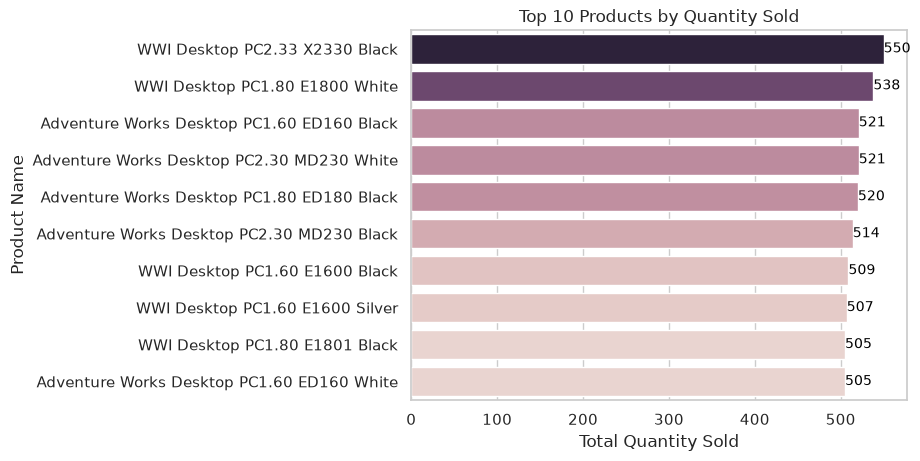

In [24]:
sns.set(style="whitegrid")
sns.barplot(
    data=sales_summary.head(10),
    x="Total Quantity Sold",
    y="Product Name",
    hue="Total Quantity Sold",
    legend=False
)
plt.title("Top 10 Products by Quantity Sold")
bar_labels = [f"{x:,.0f}" for x in sales_summary.head(10)["Total Quantity Sold"]]
for index, value in enumerate(bar_labels):
    plt.text(
        sales_summary.head(10)["Total Quantity Sold"].values[index],
        index,
        value,
        va="center",
        ha="left",
        fontsize=10,
        color="black",
    )
plt.show()

## 2.2: Calculating profits, revenue, and cost.

In [25]:
Total_Profit = sales_summary["Total Profit (USD)"].sum()
Total_Revenue = sales_summary["Total Revenue (USD)"].sum()
Total_Cost = sales_summary["Total Cost (USD)"].sum()
print(f'The total profit is: ${Total_Profit:,.2f}')
print(f'The total revenue is: ${Total_Revenue:,.2f}')
print(f'The total cost is: ${Total_Cost:,.2f}')

The total profit is: $32,662,688.38
The total revenue is: $55,755,479.59
The total cost is: $23,092,791.21


### Visualization

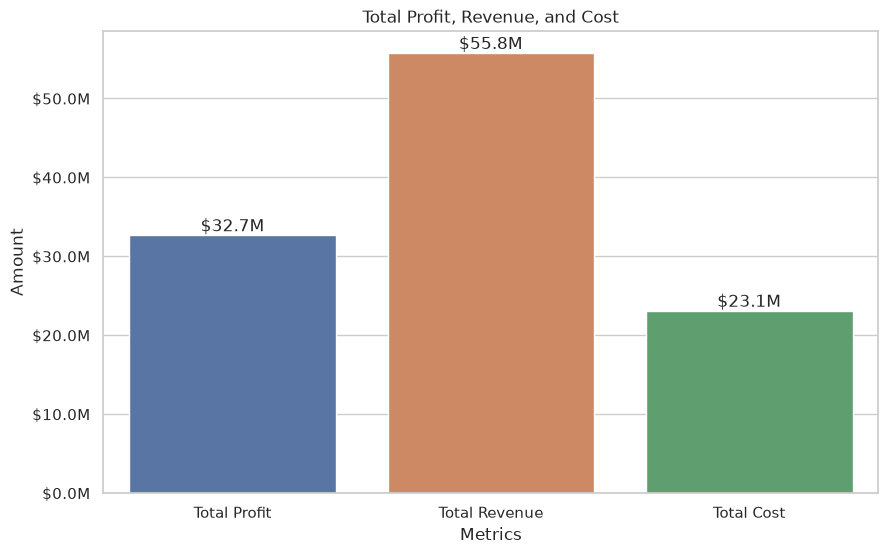

In [26]:
Total_Profit_Spent_Cost = pd.DataFrame({
    "Metric": ["Total Profit", "Total Revenue", "Total Cost"],
    "Amount": [Total_Profit, Total_Revenue, Total_Cost]
})
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    data = Total_Profit_Spent_Cost,
    x = "Metric",
    y = "Amount",
    hue = "Metric",
)

# Concept of formating axis tick labels as such obtained online from https://stackoverflow.com/questions/53747298/how-to-format-axis-tick-labels-from-number-to-thousands-or-millions-125-436-to
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, pos: f"${y*1e-6:.1f}M")
)

bar_labels = [f"${x*1e-6:.1f}M" for x in Total_Profit_Spent_Cost["Amount"]]
for i, label in enumerate(bar_labels):
    plt.text(i, Total_Profit_Spent_Cost["Amount"][i], label, ha='center', va='bottom')

plt.xlabel("Metrics")
plt.title("Total Profit, Revenue, and Cost")  
plt.show()

#### Profit Margins

In [27]:
profit_margin = Total_Profit / Total_Revenue * 100
print(f'The profit margin is: {profit_margin:.2f}%')

The profit margin is: 58.58%


## 2.3: Delivery analysis

- In the sales table, there are attributes for both 'Order Date' and 'Delivery Date'.
- These attributes can help us analyse delivery times for each sale of a product.
- As stated earlier, any record missing a delivery date is treated as an 'in-store purchase'.

### Checking on the completed deliveries

- From the output we can surmise that out of the 62,884 sales. 49,719 are 'in-store purchases' and the rest are 'deliveries'.
- This means that in-store purchases make up 79.06% of the total products sold.


In [28]:
in_store_purchase = Sales['Delivery Date'].isnull().sum()
print(f'The number of in-store purchases is: {in_store_purchase}')
completed_deliveries = Sales['Delivery Date'].notnull().sum()
print(f'The number of purchases requiring deliveries is: {completed_deliveries}')
print(f'The in-store purchases make up {in_store_purchase / (in_store_purchase + completed_deliveries) * 100:.2f}% of the total products sold.')

The number of in-store purchases is: 49719
The number of purchases requiring deliveries is: 13165
The in-store purchases make up 79.06% of the total products sold.


### Delivery Duration

- With the new-found stats regarding sales that required deliveries we can calculate the average time of all delivery durations.

In [29]:
Order_dates = pd.to_datetime(Sales['Order Date'], errors='coerce')
Delivery_dates = pd.to_datetime(Sales['Delivery Date'], errors='coerce')
Delivery_times = (Delivery_dates - Order_dates).dt.days
Completed_delivery_times = Delivery_times[Delivery_times.notnull()]
print(f'The average delivery time is: {Completed_delivery_times.mean():.2f} days')

The average delivery time is: 4.53 days


### Visualization

- To plot the distribution of delivery times (in days) I had decided on using a countplot due to it being able to automatically centre discrete like data and avoid me having to manaully calculate an appropriate bin-width.
- As can be seen in the visualization output, the delivery times are positively skewed with the mode found at '4.0' days.
- This means that a large concentration of delivery order take  between 3-5 days to fullfill and very few orders take longer than that.
-We can also see the plot has a long tail trailing towards '17.0' days meaning that there is a small concentration of orders that take that long to be fullfilled. (With the number of orders decreasing with an increase in delivery time)

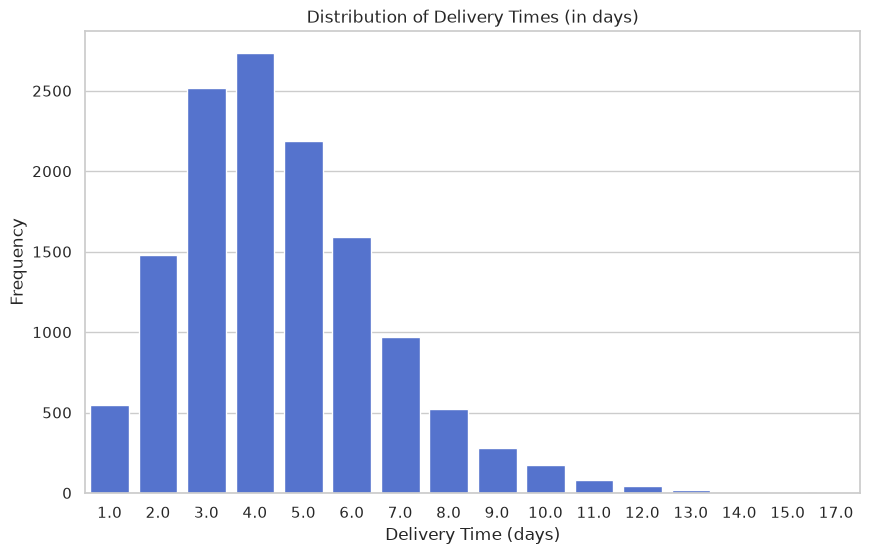

In [30]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x=Completed_delivery_times, 
    color="royalblue"
)

plt.title("Distribution of Delivery Times (in days)")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Frequency")
plt.show()

# 3. Statistical Analysis

## Test 1: Two-Sample t-Test (Online vs. In-Store Spending)

- First test I performed was a sample t-Test to to whether there is singificant difference between online vs in-store spending.
- The focus tables for this test are Stores.csv, Products.csv, and Sales.csv
- Within the Stores.csv there is the 'StoreKey' attribute that assigns a unique id to each store. However, the 'StoreKey' 0 is assigned to the online store. 
- We are then able to group sales according to whether their 'StoreKey' is 0 (online) or otherwise and see if there is a significant difference.
- I created a dataframe 'sales_full' which contains all necessary attributes from Products.csv, Sales.csv, and Stores.csv to perform this test.

In [31]:
# Clean 'Unit Price USD' in Products
# As stated in the 2.1: Sales summary, the attribute 'Unit Price USD' in Products is recorded as "$ xxxx" which makes it difficult to perorm calculations with. 
# Therefore, we will remove the "$" and convert the column to numeric values.
if Products["Unit Price USD"].dtype == "object":
    Products["Unit Price USD"] = (
        Products["Unit Price USD"]
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
    )
    Products["Unit Price USD"] = pd.to_numeric(
        Products["Unit Price USD"], errors="coerce"
    )

# Merge Unit Price USD into Sales using ProductKey
sales_full = Sales.merge(
    Products[["ProductKey", "Unit Price USD"]], on="ProductKey", how="left"
)

# Calculate the total transaction spend per row
sales_full["Total Spend USD"] = (
    sales_full["Quantity"] * sales_full["Unit Price USD"]
)

# Split into Online vs In-Store (StoreKey == 0 indicates Online)
online_spend = sales_full[sales_full["StoreKey"] == 0][
    "Total Spend USD"
].dropna()
store_spend = sales_full[sales_full["StoreKey"] > 0]["Total Spend USD"].dropna()

# Run Welch's t-test (handles unequal sample sizes and variances)
# This idea to perform a t-test this way was obtained from https://datagy.io/t-test-python/ (Section: "Perform a Two-Sample T-Test in Python")
t_stat, p_val = stats.ttest_ind(online_spend, store_spend, equal_var=False)

print(f"Online Mean Spend: ${online_spend.mean():.2f}")
print(f"In-Store Mean Spend: ${store_spend.mean():.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print(
        "Result: Statistically significant difference between online and in-store order values (reject H0)."
    )
else:
    print(
        "Result: No statistically significant difference between online and in-store order values (fail to reject H0)."
    )

Online Mean Spend: $866.26
In-Store Mean Spend: $892.04
t-statistic: -1.6398
p-value: 1.0107e-01
Result: No statistically significant difference between online and in-store order values (fail to reject H0).


## Test 2: One-Way ANOVA (Order Quantities Across Product Categories)

- The second test I performed was a one-way ANOVA to test whethere there is significant difference in order quantities across product categories.
- The focus tables for this test were Sales.csv and Products.csv.
- I created a new dataframe that contains all necessary attributes from Sales.csv and Products.csv to perform this test.

In [32]:
# Merge Sales with Products to get Category
sales_merged = Sales.merge(Products[['ProductKey', 'Category']], on='ProductKey', how='left')

# Group quantities into separate arrays per category
categories = sales_merged['Category'].dropna().unique()
category_groups = [sales_merged[sales_merged['Category'] == cat]['Quantity'].dropna() for cat in categories]

# Run One-Way ANOVA
f_stat, p_val = stats.f_oneway(*category_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print(
        "Result: Statistically significant difference in purchase quantities among categories (reject H0).")
else:
    print("Result: No statistically significant difference in purchase quantities among categories (fail to reject H0).")

F-statistic: 1.3247
p-value: 2.3367e-01
Result: No statistically significant difference in purchase quantities among categories (fail to reject H0).


# 4. Exploratory Data Analysis

## 4.1: Most abundant Category

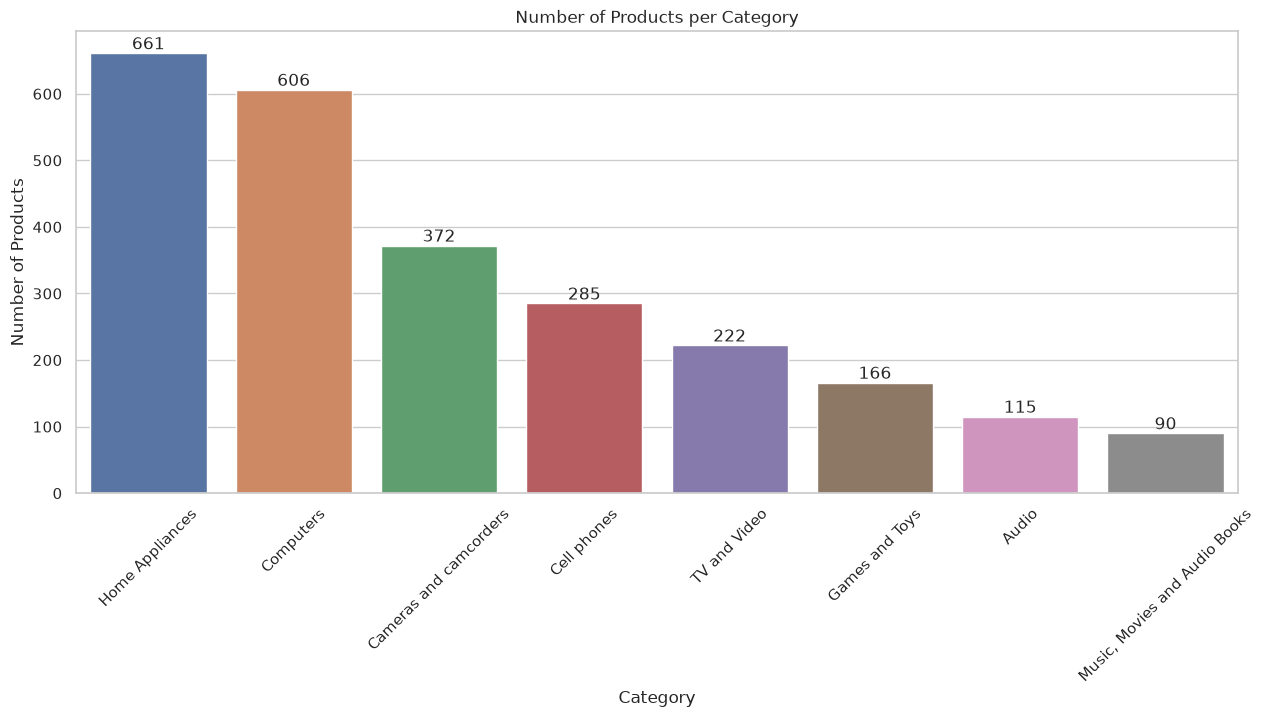

In [33]:
PC=Products['Category'].value_counts().head(10)
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))
sns.barplot(
    x=PC.index,
    y=PC.values,
    hue = PC.index
)
plt.title('Number of Products per Category')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.bar_label = [f"{x}" for x in PC.values]
for i, label in enumerate(plt.bar_label):
    plt.text(i, PC.values[i], label, ha='center', va='bottom')
plt.show()

In [34]:
Category_Percentage = Products['Category'].value_counts(normalize=True).head(10) * 100
Category_Percentage

Category
Home Appliances                  26.261422
Computers                        24.076281
Cameras and camcorders           14.779499
Cell phones                      11.323004
TV and Video                      8.820024
Games and Toys                    6.595153
Audio                             4.568931
Music, Movies and Audio Books     3.575685
Name: proportion, dtype: float64

## 4.2: Most abundant Subcategory

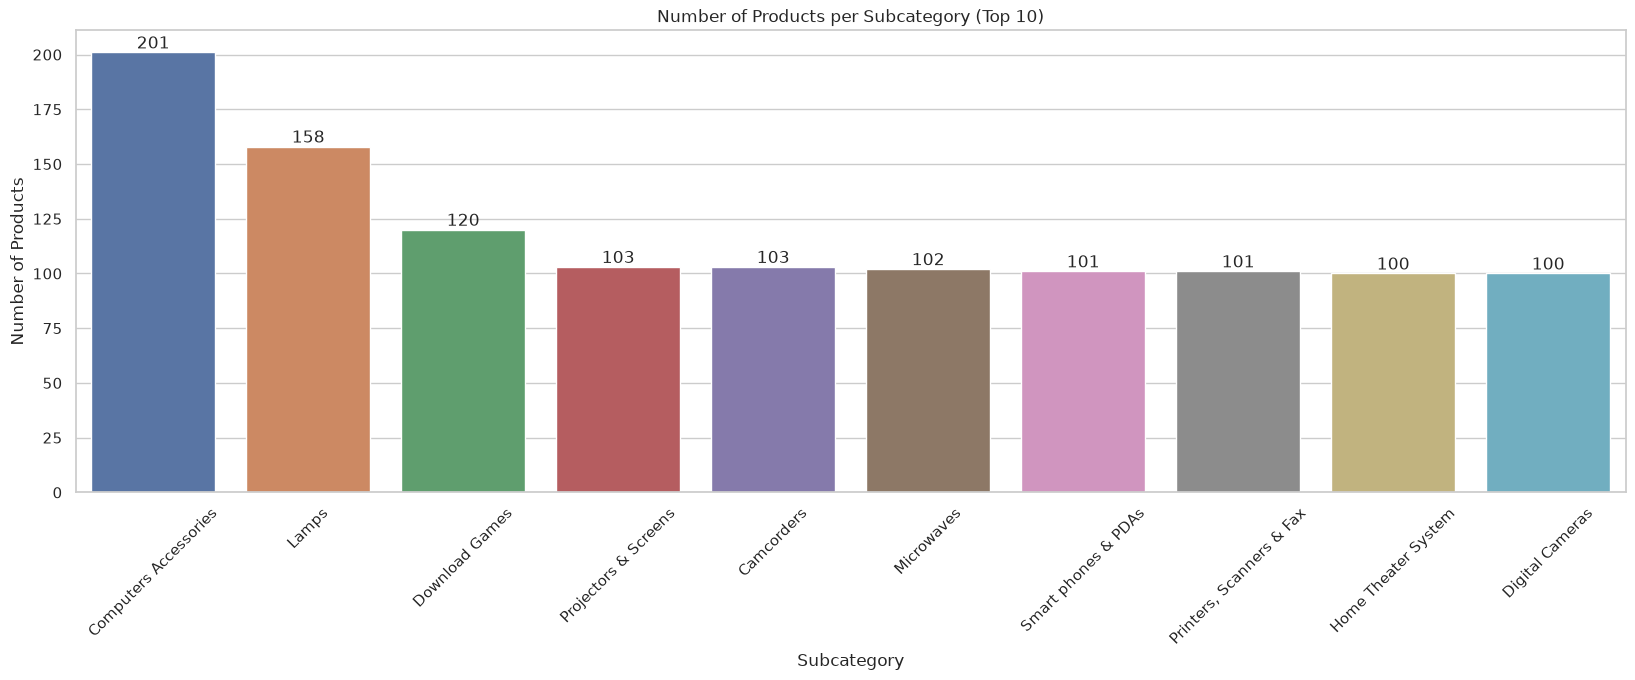

In [35]:
PS=Products['Subcategory'].value_counts().head(10)
sns.set(style="whitegrid")
plt.figure(figsize=(20, 6))
sns.barplot(
    x=PS.index,
    y=PS.values,
    hue=PS.index
)
plt.title('Number of Products per Subcategory (Top 10)')
plt.xlabel('Subcategory')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.bar_label = [f"{x}" for x in PS.values]
for i, label in enumerate(plt.bar_label):
    plt.text(i, PS.values[i], label, ha='center', va='bottom')
plt.show()

In [36]:
Subcategory_percentage = Products['Subcategory'].value_counts(normalize=True).head(10) * 100
Subcategory_percentage

Subcategory
Computers Accessories       7.985697
Lamps                       6.277314
Download Games              4.767580
Projectors & Screens        4.092173
Camcorders                  4.092173
Microwaves                  4.052443
Smart phones & PDAs         4.012714
Printers, Scanners & Fax    4.012714
Home Theater System         3.972984
Digital Cameras             3.972984
Name: proportion, dtype: float64

## 4.3: Country with highest customer representation

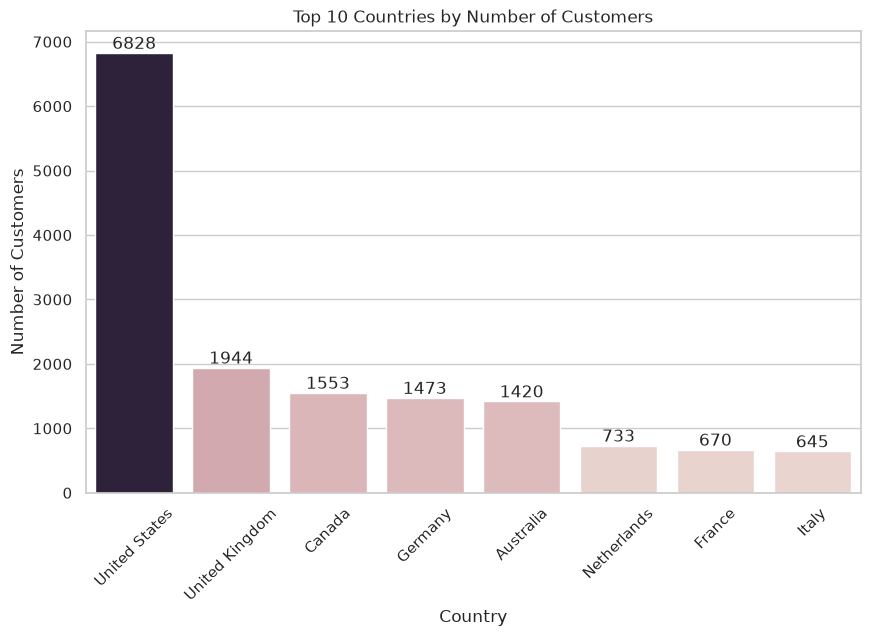

In [37]:
CC=Customers['Country'].value_counts().head(10)
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    x=CC.index,
    y=CC.values,
    hue=CC.values,
    legend=False
)
plt.title("Top 10 Countries by Number of Customers")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.bar_label = [f"{x}" for x in CC.values]
for i, label in enumerate(plt.bar_label):
    plt.text(i, CC.values[i], label, ha='center', va='bottom')
plt.show()

In [38]:
Customers_percentage = Customers['Country'].value_counts(normalize=True) * 100
Customers_percentage

Country
United States     44.726844
United Kingdom    12.734181
Canada            10.172933
Germany            9.648893
Australia          9.301716
Netherlands        4.801520
France             4.388838
Italy              4.225075
Name: proportion, dtype: float64

## 4.4: Country with the highest number of physical stores

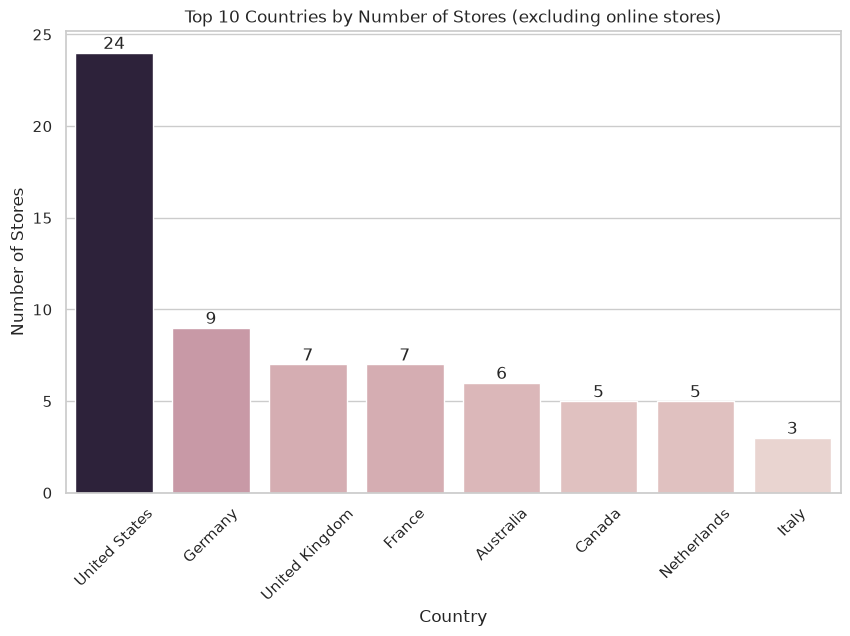

In [39]:
SC = Stores[Stores['StoreKey']!=0]['Country'].value_counts().head(10)
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(
    x=SC.index,
    y=SC.values,
    hue=SC.values,
    legend=False
)
plt.title("Top 10 Countries by Number of Stores (excluding online stores)")
plt.xlabel("Country")
plt.ylabel("Number of Stores")
plt.xticks(rotation=45)
plt.bar_label = [f"{x}" for x in SC.values]
for i, label in enumerate(plt.bar_label):
    plt.text(i, SC.values[i], label, ha='center', va='bottom')
plt.show()


In [40]:
Stores_percentage = Stores[Stores['StoreKey']!=0]['Country'].value_counts(normalize=True) * 100
Stores_percentage

Country
United States     36.363636
Germany           13.636364
United Kingdom    10.606061
France            10.606061
Australia          9.090909
Canada             7.575758
Netherlands        7.575758
Italy              4.545455
Name: proportion, dtype: float64

# 5. Conclusions

## 5.1: Summary

### 5.1.1: Financial Overview and Margins

- Exceptional Gross Profit: 
    - Across all sale transactions, the business realized a gross profit margin of *58.58%* (approximately $32.7M profit on $55.8M gross revenue.)
- Margin Scope: 
    - This reflects pure gross product markup (Unit Price - Unit Cost) before operating overhead costs (store leases, fulfillment logistics, sales labor, etc).

### 5.1.2: Core Revenue Drivers

- Flagship Profit Engines: 
    - The *WWI Desktop PC2.33 X2330 Black* is the single most valuable item, generating $505,450.00 in revenue and $337,986.00 in gross profit alone.
- Top 10 Consistency: 
    - 7 of the top 10 products by quantity sold belong to either the *WWI Desktop PC* or *Adventure Works Desktop PC* product lines. Showing that the customer base highly favour the retailer's desktop products.

### 5.1.3: Delivery Distributions

- Fulfillment Segmentation: 
    - In-store purchases account for *79.06% of all transactions (49,719 orders)*, which are fulfilled immediately at the point of sale with zero shipping lag.
- Right-Skewed Online Fulfillment: 
    - Among the remaining 13,165 delivered orders, shipping durations range from *1 to 17 days*, with an average duration of *4.5 days* and a large concentration of orders fullfilled within *3 to 5 days*. 
- The "Long Tail" Bottleneck: 
    - The distribution displays a pronounced positive skewness. While the majority of packages arrive within 5 business days, an extended right tail stretching up to 17 days exposes logistical vulnerabilities.


### 5.1.4: Statistical Inference

- 2 sample hypothesis testing results: 
  - Welch’s two-sample t-test evaluated order spend between online and in-store purchases:
    - In-Store Mean Spend: $892.04
    - Online Mean Spend: $866.26
    - t-statistic = 1.6398 
    - p-value = 0.10107
  - Because p > 0.05, we fail to reject the null hypothesis H0$. There is *no statistically significant difference* in average spend across physical stores and the digital store. Customers exhibit equivalent spending power regardless of the purchase channel, indicating consistent customer intent across platforms.

- One-way ANOVA hypothesis testing results:
  - Running one-way ANOVA evaluated order quantities across product categories:
    - F-statistic: 1.3247
    - p-value = 0.23367
  - Because p > 0.05, we fail to reject the null hypothesis H0. There is *no statistically significant difference* in order quantities across the different product categories. Customers show no significant favour towards any particular category indicating consistent customer consuption across product categories.


### 5.1.5: Exploratory Data Analysis (EDA)

- Category analysis: 
    - Of all categories, retailer mostly produces Home Appliances and Computers. Which account for about ~*50%* of all products made by the retailer.
- Customer analysis: 
    - An analysis of customer records shows that a large number of the retailer's customer base come from the United States.
- Store location analysis:
    - An analysis of store physical locations shows that United States has the largest number of physical stores.

- *Summary*
    - The number of physical stores located in the United State might be the cause for such a high customer base in the country. Further analysis of correlation might reveal as such.

## 5.2: References

***Websites and Links***
- [Global Electronics Retailer](https://mavenanalytics.io/data-playground/global-electronics-retailer) - table used
- [Perform a Two-Sample T-Test in Python](https://datagy.io/t-test-python/) - Guide on how to perform a 2 sample t-test (Section: "Perform a Two-Sample T-Test in Python")
- [How to format axis-tick-label from number to thousands or Millions (125,436 to 125.4k)](https://stackoverflow.com/questions/53747298/how-to-format-axis-tick-labels-from-number-to-thousands-or-millions-125-436-to) - Stack Overflow forum on how to format axis tick labels

***Python packages***
- Pandas
    - For creating dataframes and data manipulation
- Matplotlib
    - for seaborn visualization formatting
- Seaborn
    - For visualization outputs
- scipy 
    - For hypothesis testing
